## 0. Preparation
### 0.1 Load Modules

In [51]:
import gdown
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import cmcrameri.cm as cmc
import hvplot.xarray

### 0.2 Download data

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.
--> downloads interpolated image of the 1st of July 1st of each 3-year block

Band positions: *1. Blue, 2. Green , 3. Red, 4. NIR, 5. SWIR1, 6. SWIR2, 7. TIR1*

#### Automatic download from Google Drive:

In [52]:
# Create data directory
data_folder = "../data"
os.makedirs(data_folder, exist_ok=True)

# Dictionary of file IDs per year(alway the first of 3-year block)
datasets = {
    1985:"1gdgTwrMUVVMpNC5YYTU3LkgNEutjRUM5",
    1988:"1lYyrBD97drS3H_pxI0nLmXpU4S9Zw8b1",
    1991:"1JxT2CNw6y1RTHXwFJ0nm-_4unLJxBRUJ",
    1994:"1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas",
    1997:"1ysdgB8XYwEEYXl578CMQzVK8ZZ2XHTku",
    2000:"1s7Nnl80wGbMh1xyEV7Dx9YqaZPNpOZb_",
    2003:"11ES9OyhetkfvH8DTOi5BCJdoWVLCCQX7",
    2006:"1S-LoLT967qDS8d1bp_wXaRnja0JscuJu",
    2009:"1doUkH38hT1tle41qeQ7AH8aDjGIQ0F90",
    2012:"1o4sFKySMZl1e2W9cGU3EyB4KCO9CvJZh",
    2015:"1XwhUhv3FW4sFx3ubGf9v-dyq9I-Idq_b",
    2018:"1t16HUGh17ldTojX3lrt3MMH_PA2R3kV4",
    2021:"1qh7ZLAOw36l28qs8JJlaKs6FzcjmLigY",
    2024:"1mc0cWZgh6rm0YfZuPlIm8FWJKvMfsDQc"
}

#create array containing all years
year_list = np.arange(1985, 2025, 3)

#loop through them an download missing files
for year in year_list:
    filepath = f"../data/LandsatComposite_Zurich_{year}.tif"
    fileID = datasets[year]
    if not os.path.exists(filepath):
        print(f"Downloading {filepath}...")
        url = f"https://drive.google.com/uc?id={fileID}"
        gdown.download(url, filepath, quiet=False)
    else:
        print(f"{filepath} already exists")


../data/LandsatComposite_Zurich_1985.tif already exists
../data/LandsatComposite_Zurich_1988.tif already exists
../data/LandsatComposite_Zurich_1991.tif already exists
../data/LandsatComposite_Zurich_1994.tif already exists
../data/LandsatComposite_Zurich_1997.tif already exists
../data/LandsatComposite_Zurich_2000.tif already exists
../data/LandsatComposite_Zurich_2003.tif already exists
../data/LandsatComposite_Zurich_2006.tif already exists
../data/LandsatComposite_Zurich_2009.tif already exists
../data/LandsatComposite_Zurich_2012.tif already exists
../data/LandsatComposite_Zurich_2015.tif already exists
../data/LandsatComposite_Zurich_2018.tif already exists
../data/LandsatComposite_Zurich_2021.tif already exists
../data/LandsatComposite_Zurich_2024.tif already exists


### 0.3 Load Data 

In [53]:
#create empty arrays to store data
LST_array = []
Red_array = []
NIR_array = []

#add data from every year (seperat files)
for year in year_list:
        filepath = f"../data/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src: # only open needed bands
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)
            

# turn into xr-array
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")
LST = xr.concat(LST_array, dim="time")



### 0.4 calculate  °C and NDVI

In [54]:
# change LST unit from K into °C 
LST = LST - 273.15 

#calculate raw NDVI
NDVI = (NIR - Red)/(NIR + Red)

# produce thresholded layer
threshold = 0.3 # standart for mixed vegetation
NDVI_filtered = NDVI.where(NDVI >= threshold)

### 0.5 RGB picture for reference
This codeblock generates a true color image to give contex to the following analysis

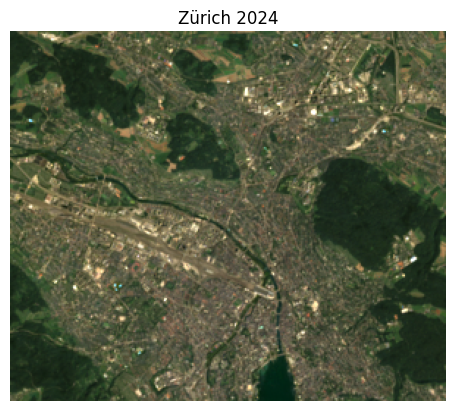

In [55]:
def normalize(array, vmin=0, vmax=0.2):
    """Normalize and clip array to a specific range (default 0 to 0.4)"""
    # Clip the array to the specified vmin and vmax
    clipped = np.clip(array, vmin, vmax)
    # Scale the clipped array to 0-1 for display
    return (clipped - vmin) / (vmax - vmin)

#select a year
reference_year = 2024
if reference_year in year_list:#check if selected year is valid
    #extract rgb bands from reference year
    with xr.open_dataset(f"../data/LandsatComposite_Zurich_{reference_year}.tif", engine = "rasterio") as src:
                # load bands and get rid of outlieres for effective visualization 
                Blue_ref = normalize(src.sel(band = 1).band_data)
                Green_ref = normalize(src.sel(band = 2).band_data)
                Red_ref = normalize(src.sel(band=3).band_data)

    #stack the bands
    rgb = np.dstack((Red_ref, Green_ref, Blue_ref))

    fig, ax = plt.subplots()
    ax.imshow(rgb)
    ax.set_title(f"Zürich {reference_year}")
    ax.set_axis_off()

else:
       print(f"{reference_year} is not an available file")

## 1. How did LST and NDVI change from 1985 to 2024?
### 1.1 Simple Visualization of the Variabels
This code produces interactive hvplot animations of LST and NDVI in the different years

In [56]:
def limits(array, p = 2):
    """returns upper and lower perectile of an array 
    (default: vmin = 2nd percentile, vmax = 98th percentile)"""
    vmin = np.percentile(array, p)
    vmax = np.percentile(array, 100-p)
    return vmin, vmax
    

#plot LST
LST_min_hv, LST_max_hv = limits(LST)

LST_hvplot = LST.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.lajolla_r,
              clim = (LST_min_hv, LST_max_hv),
              clabel = "Land Surface Temperature [°C]", 
              aspect='equal', 
              xaxis = None, yaxis = None)


NDVI_filtered = NDVI.where(NDVI >= threshold)
#plot NDVI
NDVI_min_hv, NDVI_max_hv = limits(NDVI_filtered) 
#NDVI_max_hv=np.percentile(NDVI, 98)               #only max used -->almost no negative values
NDVI_hvplot = NDVI_filtered.hvplot(x = "x", y = "y", groupby = "time", cmap = "YlGn",
              clim = (threshold, 1),# 1 = normal upper limit of NDVI
              clabel = "NDVI", 
              aspect='equal',
              shared_axes = False, 
              xaxis = None, yaxis = None,
              bgcolor="lightgray")


LST_hvplot + NDVI_hvplot

BokehModel(combine_events=True, render_bundle={'docs_json': {'6a6e554a-c5cb-4a07-a5cc-d0ba44b66846': {'version…

### 1.2 NDVI change in reference to 1985
This code calculates the difference of each layer to the reference year creates an animation through time


In [66]:
#calculate difference 
LST_dif = LST.sel(time = slice(1988,2024)) - LST.sel(time = 1985)

#set boundaries for visualisation centerd around 0
LST_min, LST_max = limits(LST_dif)
LST_boundry = max(abs(LST_min), abs(LST_max))# center around 0

#animate LST
LSTdif = LST_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.vik,
              clim = (-LST_boundry, LST_boundry),
              clabel = "Change in LST in reference to 1985", 
              aspect='equal', 
              xaxis = None, yaxis = None,
              widget_location = "bottom",
              widget_type = "scrubber")

#calculate difference 
NDVI_dif = NDVI.sel(time = slice(1988,2024)) - NDVI.sel(time = 1985)

#set boundaries for visualisation centerd around 0
NDVI_min, NDVI_max = limits(NDVI_dif)
NDVI_boundry = max(abs(NDVI_min), abs(NDVI_max))# center around 0

#animate NDVI
NDVIdif = NDVI_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.bam,
              clim = (-NDVI_boundry, NDVI_boundry),
              clabel = "Change in NDVI in reference to 1985", 
              aspect='equal', 
              xaxis = None, yaxis = None,
              widget_location = "bottom",
              widget_type = "scrubber")


#show plots
LSTdif + NDVIdif

BokehModel(combine_events=True, render_bundle={'docs_json': {'65fd18d1-0843-4b8c-9575-771558b8759c': {'version…

###  1.3 Modelling change in Collapsed space
In this Segment, the spatial extent of the data is collapsed into means, resulting in one overall value per 3-annual period. To these values, a linear model is fitted to measure the rate of change.

Text(2005, 33.5, 'Estimate: + 0.63 km^2/10yrs')

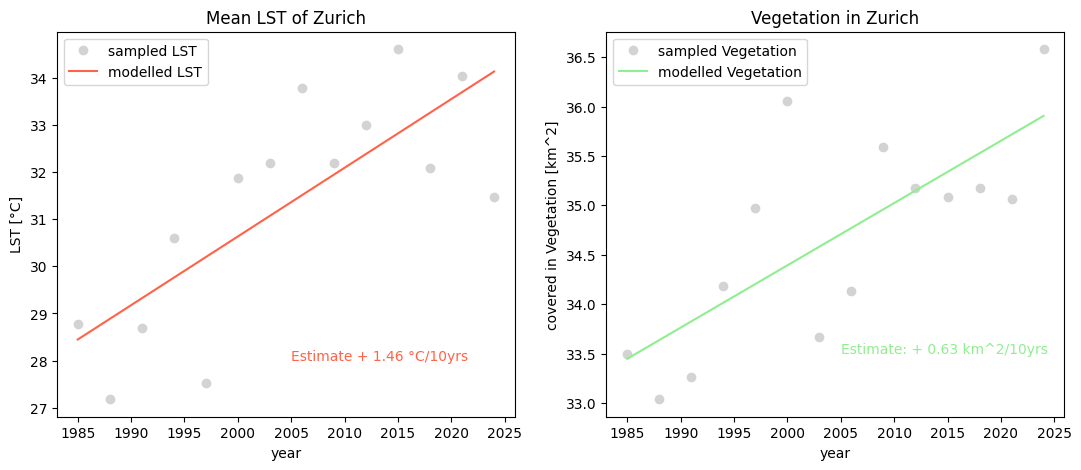

In [58]:
# change in overall NDVI aber summe aller pixel
pixelsize = NDVI.rio.resolution()
NDVI_sum = NDVI_filtered.sum(dim =["x","y"])*(0.03**2)## to get km^2 instead of pixels

NDVI_sum_fit = NDVI_sum.polyfit(dim = "time", deg = 1)
NDVI_sum_trend_line = xr.polyval(NDVI_sum.time, NDVI_sum_fit.polyfit_coefficients)

# change in overall LST
LST_mean = LST.mean(dim =["x","y"])
LST_mean_fit = LST_mean.polyfit(dim = "time", deg = 1)
LST_mean_trend_line = xr.polyval(LST_mean.time, LST_mean_fit.polyfit_coefficients)

#plotting
fig, ax = plt.subplots(1,2, figsize = (13,5))

LST_mean.plot(ax = ax[0],marker = "o", ls= "", label = "sampled LST", color = "lightgrey")
LST_mean_trend_line.plot(ax = ax[0], label = "modelled LST", color = "tomato")
ax[0].set_title("Mean LST of Zurich")
ax[0].legend()
ax[0].set_ylabel("LST [°C]")
ax[0].set_xlabel("year")
ax[0].annotate(f"Estimate + {LST_mean_fit.polyfit_coefficients[0]*10:.2f} °C/10yrs", (2005,28), color = "tomato")

NDVI_sum.plot(ax = ax[1], marker = "o", ls = "", label = "sampled Vegetation", color = "lightgrey")
NDVI_sum_trend_line.plot(ax= ax[1], label = "modelled Vegetation", color = "lightgreen")
ax[1].set_title("Vegetation in Zurich")
ax[1].legend()
ax[1].set_ylabel("covered in Vegetation [km^2]")
ax[1].set_xlabel("year")
ax[1].annotate(f"Estimate: + {(NDVI_sum_fit.polyfit_coefficients[0]*10):.2f} km^2/10yrs", (2005,33.5), color = "lightgreen")

#### NDVI explanation:
wahrscheinlich nicht siginfikant (ein Punkt im Wald ähnliche SChwankungen (siehe unten))--> evtl auch aufgrund unterschiedlichen Satelitten

#### Refrencing a single Pixel  for visual assessment of significance of NDVI

Text(0.5, 0, 'year')

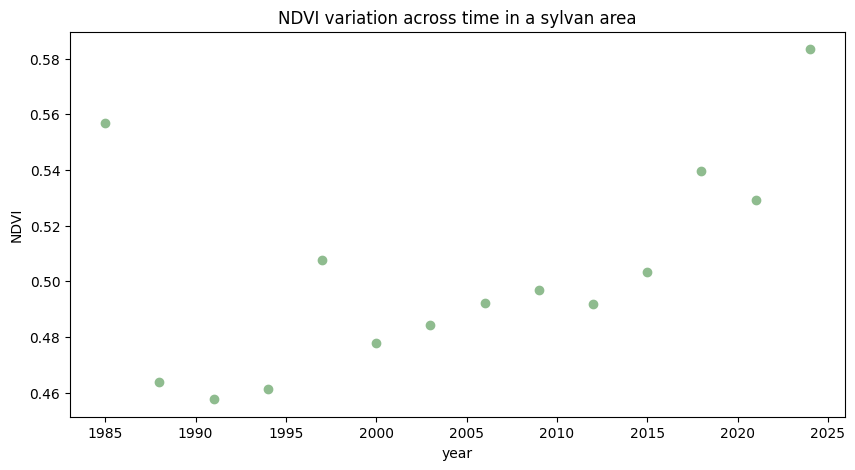

In [59]:
coordinates = (2683638.80, 1246727.00)# coordinates in LV95, place in forest on Züriberg

point_NDVI = NDVI.sel(x= coordinates[1], y = coordinates[0], method = "nearest")
point_LST = LST.sel(x= coordinates[1], y = coordinates[0], method = "nearest")

fig, ax = plt.subplots(figsize=(10,5))

point_NDVI.plot(ax = ax, color = "darkseagreen", marker = "o", lw = 0)## = Background change between years
ax.set_title("NDVI variation across time in a sylvan area")
ax.set_ylabel("NDVI")
ax.set_xlabel("year")

### 1.4 Modelling Change pixelwise
Here, similarly to 2.3, the rate of change is measured using a linear regression, but this time a regrssion is fitted for every pixel seperatly.

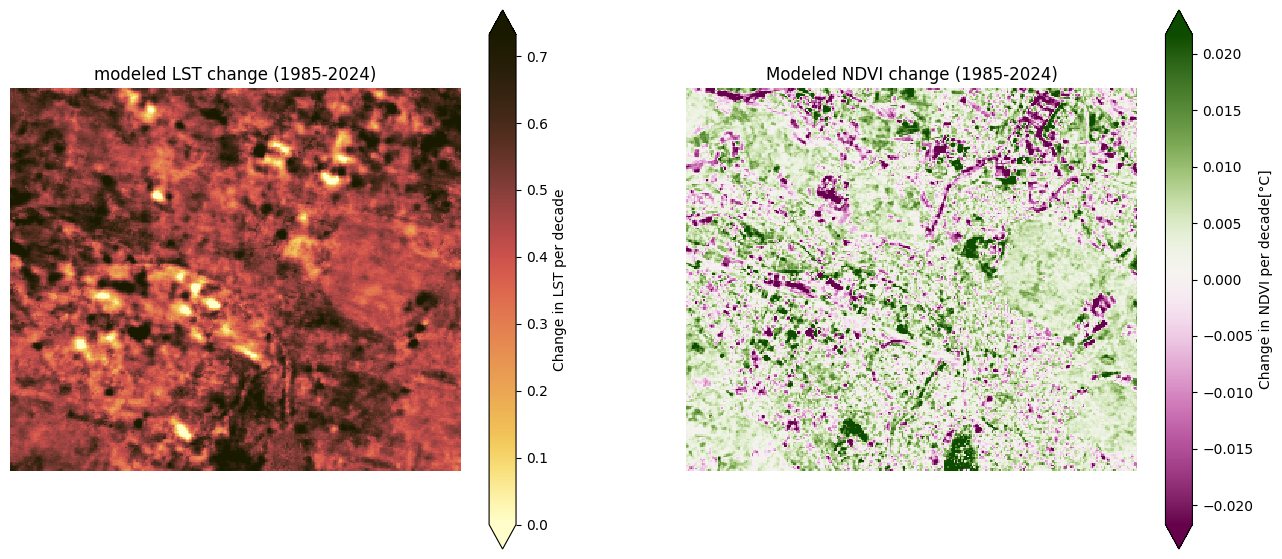

In [60]:

NDVI_fit = NDVI.polyfit(dim = "time", deg = 1)
NDVI_slope10 = NDVI_fit.polyfit_coefficients.sel(degree = 1)/3*10

# change in overall LST
LST_fit = LST.polyfit(dim = "time", deg = 1)
LST_slope10 = LST_fit.polyfit_coefficients.sel(degree = 1)/3*10 # slope is in 3 year increments (int not dateTime!)

#plotting
fig, ax = plt.subplots(1,2, figsize = (16,7))

# plot slope of LST
LST_slope_min, LST_slope_max = limits(LST_slope10)
LST_slope_boundry = max(abs(LST_slope_min), abs(LST_slope_max))

LST_slope10.plot(ax=ax[0], 
                 vmin = 0 ,
                 vmax = LST_slope_boundry, 
                 cmap = cmc.lajolla_r,
                 cbar_kwargs = {"label" : "Change in LST per decade"})
ax[0].set_axis_off()
ax[0].set_title("modeled LST change (1985-2024)")
ax[0].set_aspect('equal')

#plot slope of NDVI
NDVI_slope_min, NDVI_slope_max = limits(NDVI_slope10)
NDVI__slope_boundry = max(abs(NDVI_slope_min), abs(NDVI_slope_max))

NDVI_slope10.plot(ax= ax[1], 
                  vmin = - NDVI__slope_boundry, 
                  vmax = NDVI__slope_boundry, 
                  cmap = cmc.bam, 
                  cbar_kwargs = {"label" : "Change in NDVI per decade[°C]"})
ax[1].set_axis_off()
ax[1].set_title("Modeled NDVI change (1985-2024)")
ax[1].set_aspect('equal')

## 2. How do NDVI und LST correlate?
### 2.1 Analysis of one year
Here, we fit a linear regression with land Surface Temperature as the response and NDVI as the explaner variable. To better see the relation between the 2 variables, we only look at one year, otherwise the effect of climate change masks the patterns.

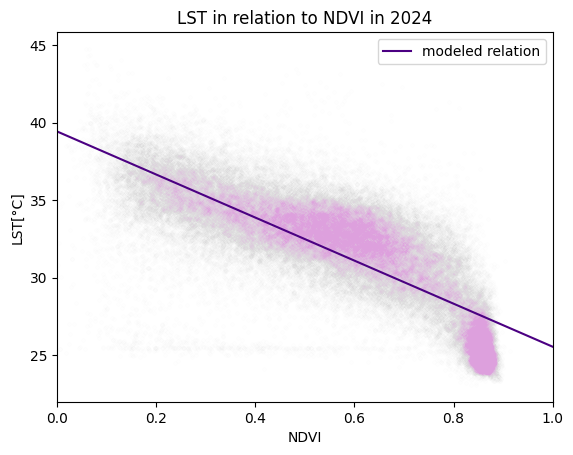

In [61]:
#extract data
year = 2024 ## change year
NDVI_y = NDVI.sel(time = year, method = "nearest")
LST_y = LST.sel(time=year, method = "nearest")

# calculate correlation
LST_NDVI_y = np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
intercept = LST_NDVI_y[1]
slope = LST_NDVI_y[0]

#plot LST against NDVI
fig, ax = plt.subplots()

ax.scatter(NDVI_y, LST_y, marker = ".", alpha = 0.005, c ="plum")
ax.axline((0,intercept),slope=slope, color = "indigo", label = "modeled relation")
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_title(f"LST in relation to NDVI in {year}")
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")
ax.legend()


### 2.2 Does the Correlation change with the advance of climate change?

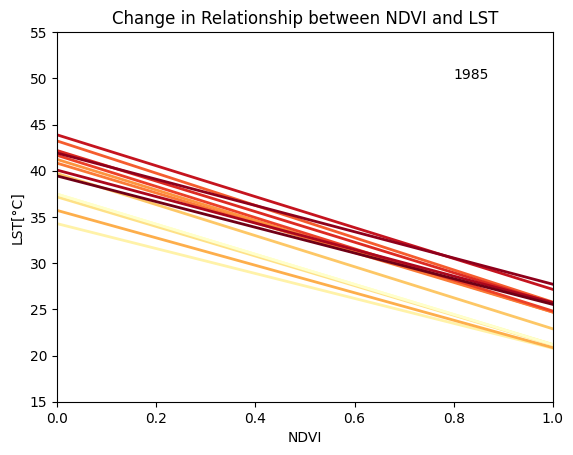

In [62]:
## animation

fig, ax = plt.subplots()
#configure ax
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)
ax.set_title("Change in Relationship between NDVI and LST")
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")

# 1 for ervery year
colors = colors = ['#ffffcc', '#fff2a8', '#fee187', '#fdc766', '#fdae4b', '#fd943f', '#fb7a36',
                    '#f55c2e', '#ec4027', '#dc2a22', '#c5141f', '#ab071d', '#8e001b', '#700016']

#generate slope and intercept for every year
year_fits = []
for i, year in enumerate(NDVI.time.values):
    NDVI_y = NDVI.sel(time = year)
    LST_y = LST.sel(time = year)
    LST_NDVI_y= np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
    intercept_y = LST_NDVI_y[1]
    slope_y = LST_NDVI_y[0]

    year_fits.append({"intercept": intercept_y,
                       "slope" : slope_y, 
                       "color" : colors[i], 
                       "label" : f"{year}"})

# add year of annotation
time = ax.annotate("", (0.8,50))

#define what changes in animation with each frame
def update(frame):
    """takes the frame and draws the corrsponding line, updates the label to fit the time"""
    #get year specific data
    fit = year_fits[frame]

    #draw line
    line = ax.axline(
        (0, fit["intercept"]),
        slope=fit["slope"],
        color=fit["color"],
        linewidth=2)
    
    
    #update year annotation
    time.set_text(fit["label"])
    return line, time

#create animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(year_fits),
    interval=800)



display(HTML(ani.to_jshtml()))

